## Sentiment Analysis on US Airline Reviews

Lohitha Velthuri

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense, Dropout, SpatialDropout1D
from tensorflow.keras.layers import Embedding

#df = pd.read_csv("./Tweets.csv")ra
#df = pd.read_csv(r"C:\Users\LOHITHA VELTHURI\Documents\Downloads\aclImdb_v1.tar.gz")

This is a dataset of 25,000 movies reviews from IMDB, labeled by sentiment (positive/negative). Reviews have been preprocessed, and each review is encoded as a list of word indexes (integers). For convenience, words are indexed by overall frequency in the dataset, so that for instance the integer "3" encodes the 3rd most frequent word in the data. This allows for quick filtering operations such as: "only consider the top 10,000 most common words, but eliminate the top 20 most common words".

Arguments

path: where to cache the data (relative to ~/.keras/dataset).
num_words: integer or None. Words are ranked by how often they occur (in the training set) and only the num_words most frequent words are kept. Any less frequent word will appear as oov_char value in the sequence data. If None, all words are kept. Defaults to None.
skip_top: skip the top N most frequently occurring words (which may not be informative). These words will appear as oov_char value in the dataset. When 0, no words are skipped. Defaults to 0.
maxlen: int or None. Maximum sequence length. Any longer sequence will be truncated. None, means no truncation. Defaults to None.
seed: int. Seed for reproducible data shuffling.
start_char: int. The start of a sequence will be marked with this character. 0 is usually the padding character. Defaults to 1.
oov_char: int. The out-of-vocabulary character. Words that were cut out because of the num_words or skip_top limits will be replaced with this character.
index_from: int. Index actual words with this index and higher.
Returns

Tuple of Numpy arrays: (x_train, y_train), (x_test, y_test).

x_train, x_test: lists of sequences, which are lists of indexes (integers). If the num_words argument was specific, the maximum possible index value is num_words - 1. If the maxlen argument was specified, the largest possible sequence length is maxlen.

y_train, y_test: lists of integer labels (1 or 0).

In [19]:
from keras.datasets import imdb
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense
from keras.preprocessing.sequence import pad_sequences

# 1. Load dataset
ds=(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

# 2. Pad sequences (for uniform input length)
X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)

# 3. Build model
model = Sequential()
model.add(Embedding(5000, 32, input_length=200))
model.add(LSTM(50))
model.add(Dense(1, activation='sigmoid'))

# 4. Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 5. Train model
model.fit(X_train, y_train, epochs=3, batch_size=64, validation_data=(X_test, y_test)) 

C:\Users\LOHITHA VELTHURI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 191ms/step - accuracy: 0.7610 - loss: 0.4685 - val_accuracy: 0.8571 - val_loss: 0.3529
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 69s 176ms/step - accuracy: 0.8888 - loss: 0.2797 - val_accuracy: 0.8677 - val_loss: 0.3166
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 178ms/step - accuracy: 0.9063 - loss: 0.2369 - val_accuracy: 0.8720 - val_loss: 0.3066


In [14]:
X_train = list(X_train)

# Build DataFrame
df_train= pd.DataFrame({
    'review': X_train,
    'label': y_train
})
print(df_train.head())

                                              review  label
0  [5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, ...      1
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 194, 1153...      0
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...      0
3  [4, 341, 7, 27, 846, 10, 10, 29, 9, 1906, 8, 9...      1
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...      0


The 'review' column will contain lists of integers, not text.

To decode those integers into actual words, you'll need the word index:

In [15]:
word_index = imdb.get_word_index()

# Reverse word index
reverse_word_index = {value: key for key, value in word_index.items()}

# Decode first review
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in X_train[0]])
print(decoded_review)


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly ? was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little ? that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big ? for the whole film but these children are amazing and should be ? for what they have done don't you think the whole story was so lovely because it was true and was someone's life after all that 

In [3]:
#'''import tarfile

# Path to your .tar.gz file
#file_path = r"C:\Users\LOHITHA VELTHURI\Documents\Downloads\aclImdb_v1.tar.gz"

# Extract the file
#with tarfile.open(file_path, "r:gz") as tar:
 #   tar.extractall(path="aclImdb_extracted")  # this will create a folder'''


In [23]:
import os
import pandas as pd

def load_reviews_from_folder(folder_path, label):
    data = []
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        with open(file_path, encoding='utf-8') as file:
            content = file.read()
            data.append((content, label))
    return data


# Set paths to positive and negative review folders
#pos_path = r"aclImdb_extracted\aclImdb\train\pos"
#neg_path = r"aclImdb_extracted\aclImdb\train\neg"

# Load reviews with labels
#pos_reviews = load_reviews_from_folder(pos_path, 1)
#neg_reviews = load_reviews_from_folder(neg_path, 0)
# Extract reviews and labels
reviews = []
labels = []
for review, label in ds:
    reviews.append(decoded_review(review))
    labels.append(int(label))

 # Create DataFrame
df = pd.DataFrame({'review': reviews, 'label': labels})   

# Combine and convert to DataFrame
#all_reviews = pos_reviews + neg_reviews
#df = pd.DataFrame(all_reviews, columns=['review', 'label'])

# Preview the dataset
print(df.head())


TypeError: 'str' object is not callable

In [ ]:
#df = pd.read_csv("C:\Users\LOHITHA VELTHURI\Documents\Downloads\aclImdb_v1")

In [6]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras

In [7]:
import numpy as np
import re
#from nltk.corpus import stopwords
#from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [8]:
import sys
print(sys.executable)


C:\Users\LOHITHA VELTHURI\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe


In [9]:
df.head()

NameError: name 'df' is not defined

In [ ]:
df.columns

Index(['review', 'label'], dtype='object')

In [ ]:
tweet_df = df[['review','label']]
print(tweet_df.shape)
tweet_df.head(5)

(25000, 2)


,review,label
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [ ]:
#counting missing values
tweet_df.isnull().sum()

review    0
label     0
dtype: int64

In [ ]:
#checking the distribution of target column
tweet_df['label'].value_counts()

label
1    12500
0    12500
Name: count, dtype: int64

In [ ]:
tweet_df = tweet_df[tweet_df['label'] != 'neutral']
print(tweet_df.shape)
tweet_df.head(5)

(25000, 2)


,review,label
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [ ]:
sentiment_label = tweet_df.label.factorize()
sentiment_label

(array([0, 0, 0, ..., 1, 1, 1]), Index([1, 0], dtype='int64'))

In [ ]:
tweet = tweet_df['review'].values
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(tweet)
vocab_size = len(tokenizer.word_index) + 1
encoded_docs = tokenizer.texts_to_sequences(tweet)
padded_sequence = pad_sequences(encoded_docs, maxlen=200)

In [ ]:
print(tokenizer.word_index)

{'the': 1, 'and': 2, 'a': 3, 'of': 4, 'to': 5, 'is': 6, 'br': 7, 'in': 8, 'it': 9, 'i': 10, 'this': 11, 'that': 12, 'was': 13, 'as': 14, 'for': 15, 'with': 16, 'movie': 17, 'but': 18, 'film': 19, 'on': 20, 'not': 21, 'you': 22, 'are': 23, 'his': 24, 'have': 25, 'he': 26, 'be': 27, 'one': 28, 'all': 29, 'at': 30, 'by': 31, 'an': 32, 'they': 33, 'who': 34, 'so': 35, 'from': 36, 'like': 37, 'her': 38, 'or': 39, 'just': 40, 'about': 41, "it's": 42, 'out': 43, 'has': 44, 'if': 45, 'some': 46, 'there': 47, 'what': 48, 'good': 49, 'more': 50, 'when': 51, 'very': 52, 'up': 53, 'no': 54, 'time': 55, 'she': 56, 'even': 57, 'my': 58, 'would': 59, 'which': 60, 'only': 61, 'story': 62, 'really': 63, 'see': 64, 'their': 65, 'had': 66, 'can': 67, 'were': 68, 'me': 69, 'well': 70, 'than': 71, 'we': 72, 'much': 73, 'been': 74, 'bad': 75, 'get': 76, 'will': 77, 'do': 78, 'also': 79, 'into': 80, 'people': 81, 'other': 82, 'first': 83, 'great': 84, 'because': 85, 'how': 86, 'him': 87, 'most': 88, "don't":

In [ ]:
print(tweet[0])
print(encoded_docs[0])

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!
[309, 6, 3, 1069, 209, 9, 2161, 30, 1, 169, 55, 14, 46, 82, 41, 392, 110, 138, 14, 58, 4449, 150, 8, 1, 4988, 482, 69, 5, 261, 12, 2002, 6, 73, 2425, 5, 632, 71, 6, 1, 5, 2003, 1, 1534, 34, 67,

In [ ]:
print(padded_sequence[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0  309    6    3
 1069  209    9 2161   30    1  169   55   14   46   82   41  392  110
  138   14   58 4449  150    8    1 4988  482   69    5  261   12 2002
    6   73 2425    5  632   71    6    1    5 2003    1 1534   34   67
   64  205  140   65 1230    1    4    1  223  901   29 3022   69    4
    1   10  693    2   65 1534   51   10  216    1  387    8   60    3
 1467 3712  800    5 3513  177    1  392   10 1237   30  309    3  353
  344 2974  143  130    5   28    4  126 1467 2373    5  309   10  532
   12  108 1468    4   58  555  101   12  309    6  227 4174   48    3
 2232 

In [ ]:
embedding_vector_length = 32
model = Sequential() 
model.add(Embedding(vocab_size, embedding_vector_length, input_length=200) )
model.add(SpatialDropout1D(0.25))
model.add(LSTM(50, dropout=0.5, recurrent_dropout=0.5))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid')) 
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])  
print(model.summary()) 
#no need of Flattern or GlobalMaxPooling1D instead LSTM

C:\Users\LOHITHA VELTHURI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history = model.fit(padded_sequence,sentiment_label[0],validation_split=0.2, epochs=5, batch_size=32)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 202ms/step - accuracy: 0.7157 - loss: 0.5518 - val_accuracy: 0.6238 - val_loss: 0.7249
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 165ms/step - accuracy: 0.8012 - loss: 0.4433 - val_accuracy: 0.6620 - val_loss: 0.7100
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 161ms/step - accuracy: 0.8224 - loss: 0.4032 - val_accuracy: 0.8020 - val_loss: 0.4819
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 163ms/step - accuracy: 0.8361 - loss: 0.3825 - val_accuracy: 0.7718 - val_loss: 0.5233
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 223ms/step - accuracy: 0.8374 - loss: 0.3806 - val_accuracy: 0.7206 - val_loss: 0.6045


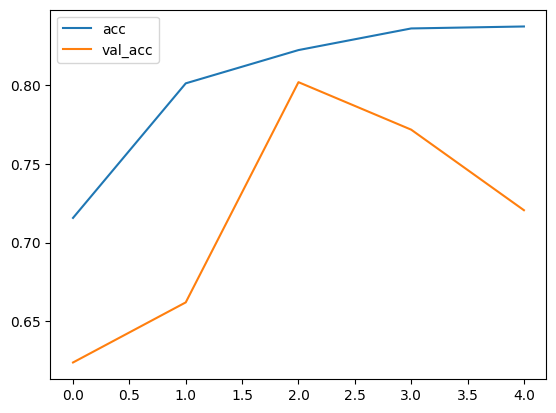

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()
plt.savefig("Accuracy plot.jpg")

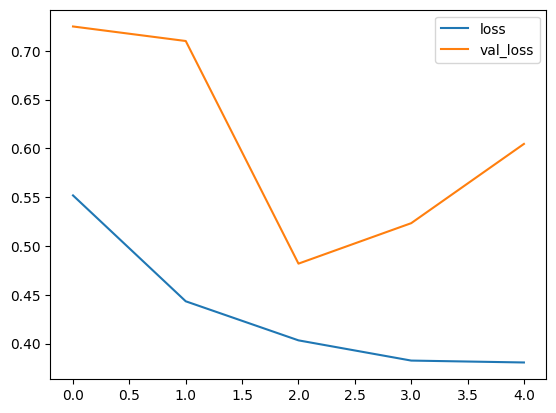

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()
plt.savefig("Loss plot.jpg")

In [ ]:
def predict_sentiment(text):
    tw = tokenizer.texts_to_sequences([text])
    tw = pad_sequences(tw,maxlen=200)
    prediction = int(model.predict(tw).round().item())
    print("Predicted label: ", sentiment_label[1][prediction])

In [ ]:
test_sentence1 = "I enjoyed my journey on this flight."
predict_sentiment(test_sentence1)

test_sentence2 = "This is the worst flight experience of my life!"
predict_sentiment(test_sentence2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted label:  1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Predicted label:  0


In [ ]:
X=tweet_df['label'].values 
Y=tweet_df['review'].values#separating data and label

In [ ]:
print(X)

[1 1 1 ... 0 0 0]


In [ ]:
print(Y)

['Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High\'s satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers\' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I\'m here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn\'t!'
 'Homelessness (or Houselessness as George Carlin stated) has been an issue for years but never a plan to help those on the street that were once considered human who did everything from

In [ ]:
#splitting data to training and testing data
X_train,X_test,Y_train,Y_test = train_test_split(Y,X,test_size=0.2,random_state=2)
#20% test data and 80% is train data

In [ ]:
print(X.shape,X_train.shape,X_test.shape)

(25000,) (20000,) (5000,)


In [ ]:
print(X_test)

["A really very bad movie, with a very few good moments or qualities.<br /><br />It starts off with pregnant Linda Blair, who runs down a hallways to flee what might be monsters or people with pitchforks, I'm not sure. She jumps through a window and wakes up, and we see she is very pregnant. The degree to which she is pregnant varies widely throughout the movie.<br /><br />She and an annoying and possibly retarded little boy who I thought was her son travel to an abandoned hotel on an island. Italian horror directors find the most irritating little boys to put in their movies! On the island already are David Hasselhoff and his German-speaking virgin girlfriend (you know how Germans are said to love Hasselhoff...). He's taking photographs, and she's translating an esoteric German book about witches, I think.<br /><br />Also traveling to the island are an older couple who have purchased it, and a real estate agent, and a woman I thought was their daughter. Evidently she was an architect,

In [ ]:
print(X_train)

["Sorry, but I will spoil both the plot line and the ending for you in hopes of avoiding a holiday fiasco like the one that I now face. The father dies and the mother asks Santa in a letter to bring him back to the family for Christmas,...and Santa does. Dad is peachy, happy healthy and totally unaware of the fact that he had died. All ends syrupy sweet.<br /><br />But as a parent who recently watched my five year-old lose his best canine friend, it was a horror flick. Now my son is convinced that all he has to do to bring his buddy back is to ask Santa! Do not underestimate the willpower of a young heart- no amount of persuasion will convince him that it was only a movie and that his dog is NOT coming back for Christmas. It has been heart breaking to watch his joy only to know that Christmas Eve he will have to face his loss afresh.<br /><br />Shame on you on behalf of all the believers that have lost a loved one recently. It is hard enough to deal with the loss one time for a child, 

In [ ]:
print(Y_train)

[0 1 0 ... 1 1 0]


In [ ]:
print(Y_test)

[0 1 1 ... 1 0 1]


In [ ]:
#converting the textual data to numerical data

vectorizer = TfidfVectorizer()
X_train=vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test) 

In [ ]:
'''vectorizer = TfidfVectorizer()
Y_train = vectorizer.fit_transform(Y_train)
Y_test=vectorizer.transform(Y_test)'''

'vectorizer = TfidfVectorizer()\nY_train = vectorizer.fit_transform(Y_train)\nY_test=vectorizer.transform(Y_test)'

In [ ]:
print(Y_train)

[0 1 0 ... 1 1 0]


In [ ]:
print(Y_test)

[0 1 1 ... 1 0 1]


In [ ]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2762276 stored elements and shape (20000, 68428)>
  Coords	Values
  (0, 56464)	0.07052976160344357
  (0, 8986)	0.06206076864701108
  (0, 66842)	0.11128454154761748
  (0, 56979)	0.08994674070446308
  (0, 7792)	0.04998607586956273
  (0, 60646)	0.15691787762174242
  (0, 46041)	0.04054511392465617
  (0, 35534)	0.05817468660694904
  (0, 2958)	0.08049785912761637
  (0, 19912)	0.05547616841721251
  (0, 23279)	0.08281694640738556
  (0, 67965)	0.05008541178716693
  (0, 30186)	0.035051424550066636
  (0, 28903)	0.08662291516927917
  (0, 42626)	0.08187923909084106
  (0, 4736)	0.11044772992865863
  (0, 28632)	0.09771247436534632
  (0, 22303)	0.11527463014324801
  (0, 35425)	0.027473720078539727
  (0, 42858)	0.07327252997468535
  (0, 60630)	0.15031491954580306
  (0, 42152)	0.09056281917614468
  (0, 21473)	0.1199403790991653
  (0, 21893)	0.05966279787816916
  (0, 16711)	0.08177607533886941
  :	:
  (19999, 2418)	0.06649550446488814
  (19999

In [ ]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 676696 stored elements and shape (5000, 68428)>
  Coords	Values
  (0, 353)	0.04535042586998272
  (0, 361)	0.044562596051890155
  (0, 362)	0.09143855644371994
  (0, 363)	0.04584697433068387
  (0, 364)	0.045471092429263685
  (0, 365)	0.041224581369924344
  (0, 368)	0.0483227446645857
  (0, 1028)	0.03915946926001158
  (0, 1147)	0.012257055104337332
  (0, 1940)	0.0200567937389584
  (0, 1956)	0.03552616131523244
  (0, 2192)	0.19626707878675922
  (0, 2413)	0.010828904023108083
  (0, 2555)	0.026303192826315536
  (0, 2562)	0.09297603259994784
  (0, 2878)	0.07874160302270462
  (0, 2958)	0.1564673668988915
  (0, 3186)	0.02875523682189567
  (0, 3209)	0.01926608118287944
  (0, 3356)	0.016163109618174375
  (0, 3371)	0.02155942705166274
  (0, 3397)	0.031227995035543986
  (0, 3496)	0.04038648518033175
  (0, 3702)	0.052002858095005995
  (0, 3736)	0.05210612088785655
  :	:
  (4999, 52091)	0.15962327777317512
  (4999, 53529)	0.042086510454459

In [ ]:
#logistic regression
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

model = OneVsRestClassifier(LogisticRegression())
model.fit(X_train, Y_train)  # assuming Y_train is still in sparse format


,estimator,LogisticRegression()
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [ ]:
#model evaluation
#accuracy score 
X_train_prediction= model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train,X_train_prediction)

In [ ]:
# Get predicted probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to binary class labels (0 or 1)
y_pred = (y_pred_probs > 0.5).astype(int)


In [ ]:
print("\n📊 Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))


📊 Confusion Matrix:
[[2180  285]
 [ 302 2233]]


In [ ]:
# 4. Precision, Recall, F1-score
print("\n📋 Classification Report:")
print(classification_report(Y_test, y_pred, target_names=["Negative", "Positive"]))


📋 Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      2465
    Positive       0.89      0.88      0.88      2535

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [ ]:
print("accuracy score on training data",training_data_accuracy)

accuracy score on training data 0.93515


In [ ]:
#saving trained model
import pickle

filename= 'trained_modell.sav'
pickle.dump(model,open(filename,'wb'))

In [ ]:
#using the saved model for future prediction
#loading the saved model
loaded_model=pickle.load(open(r"C:\Users\LOHITHA VELTHURI\Documents\Downloads\sentiment-analysis-python-code\trained_modell.sav",'rb'))

In [ ]:
import numpy as np

def get_dense_prediction(model, X):
    """
    Predict using the model and return a dense array.
    """
    prediction = model.predict(X)
    
    # Convert if it's sparse
    if hasattr(prediction, "toarray"):
        return prediction.toarray()
    
    return prediction


In [ ]:
print("Shape:", np.shape(X_new_dense))
print("Content:", X_new_dense)


Shape: (1,)
Content: [0]


In [ ]:
print(type(X_train))


<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
#dealing with sparse matrix predictions (most likely from a multi-label classification model). When you call model.predict(), it gives you a sparse matrix, and yes — if you want to use or compare its values, you must convert it to a dense array.

X_new = X_test[45]
Y_true = Y_test[45]

X_new_dense = get_dense_prediction(model, X_new)

# Now just work with the dense array
if X_new_dense[0] == 0 and X_new_dense[0] == 0:
    print("Negative for both classes")
else:
    print("Positive class detected")


Negative for both classes


In [ ]:
X_new = X_test[200]
Y_true = Y_test[200]

# Ensure 2D shape for single sample
prediction = model.predict(X_new.reshape(1, -1))

# Convert to dense array if needed
if hasattr(prediction, "toarray"):
    prediction = prediction.toarray()

print("True label:", Y_true)
print("Predicted:", prediction)


True label: 0
Predicted: [0]


In [ ]:
X_new = X_test[203]
Y_true = Y_test[203]
prediction = loaded_model.predict(X_new.reshape(1, -1))
#print(prediction)

print("True label:", Y_true)
print("Prediction:", prediction)
if(prediction[0] == 0):
    print("negative tweet")

else:
    print("positive tweet")

True label: 0
Prediction: [1]
positive tweet


In [ ]:
X_new = X_test[230]
Y_true = Y_test[230]
prediction = loaded_model.predict(X_new)
print("True label:", Y_true)
print("prediction:",prediction)

if(prediction[0] == 0):
    print("negative tweet")

else:
    print("positive tweet")

True label: 1
prediction: [0]
negative tweet
